In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

PROJECT_PATH = '/Users/kamilmadey/Desktop/ercot_forecasting_project/'
raw_path = os.path.join(PROJECT_PATH, 'data', 'raw')
interim_path = os.path.join(PROJECT_PATH, 'data', 'interim')

df = pd.read_parquet(interim_path + '/merged_all_data.parquet')

In [6]:
df.isnull().sum()

timestamp                0
RT_price               309
DAM_price              384
hub_load               192
load_total             192
temperature              0
humidity                 0
windspeed                0
precipitation            0
TotalResourceMW          0
PVGRPP_SYSTEM_WIDE       5
STPPF_SYSTEM_WIDE        5
COP_HSL_SYSTEM_WIDE      7
WGRPP_LZ_WEST            0
STWPF_LZ_WEST            0
COP_HSL_LZ_WEST          0
WGRPP_SYSTEM_WIDE        0
load_fcst_west           0
load_fcst_system         0
PRC                      0
RT_DAM_spread          693
dtype: int64

In [24]:
print(df['WGRPP_LZ_WEST'].quantile([0.95, 0.99, 1.0]))

0.95     16191.12
0.99     19573.56
1.00    190508.80
Name: WGRPP_LZ_WEST, dtype: float64


In [4]:
print(df[df['PRC'].isna()][['timestamp']])


                timestamp
1730  2021-03-14 02:00:00
10466 2022-03-13 02:00:00
19202 2023-03-12 02:00:00
27938 2024-03-10 02:00:00
36674 2025-03-09 02:00:00


In [5]:
df = df.dropna(subset=['PRC'])
df = df.drop(columns=['TotalResourceMWZoneWest'])

## PRC over time

Text(0, 0.5, 'PRC (MW)')

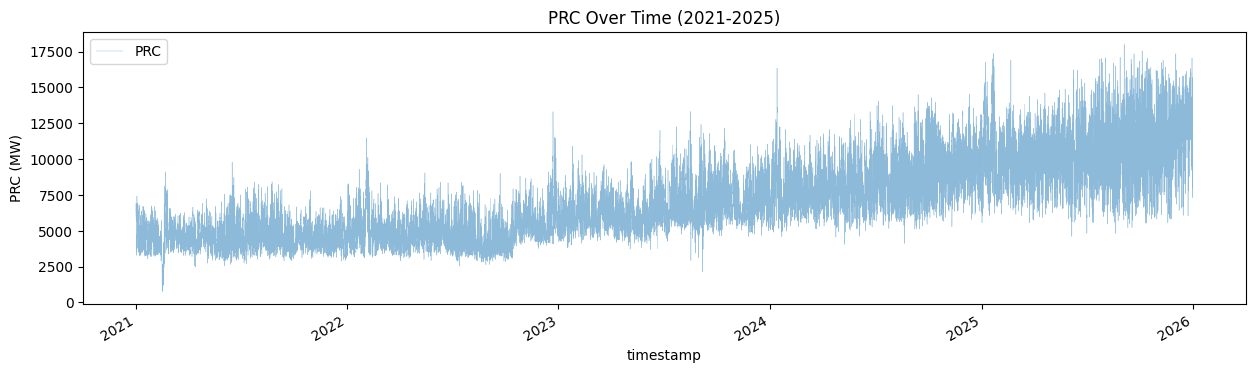

In [7]:
fig, ax = plt.subplots(figsize=(15, 4))
df.plot(x='timestamp', y='PRC', ax=ax, linewidth=0.3, alpha=0.5)
ax.set_title('PRC Over Time (2021-2025)')
ax.set_ylabel('PRC (MW)')

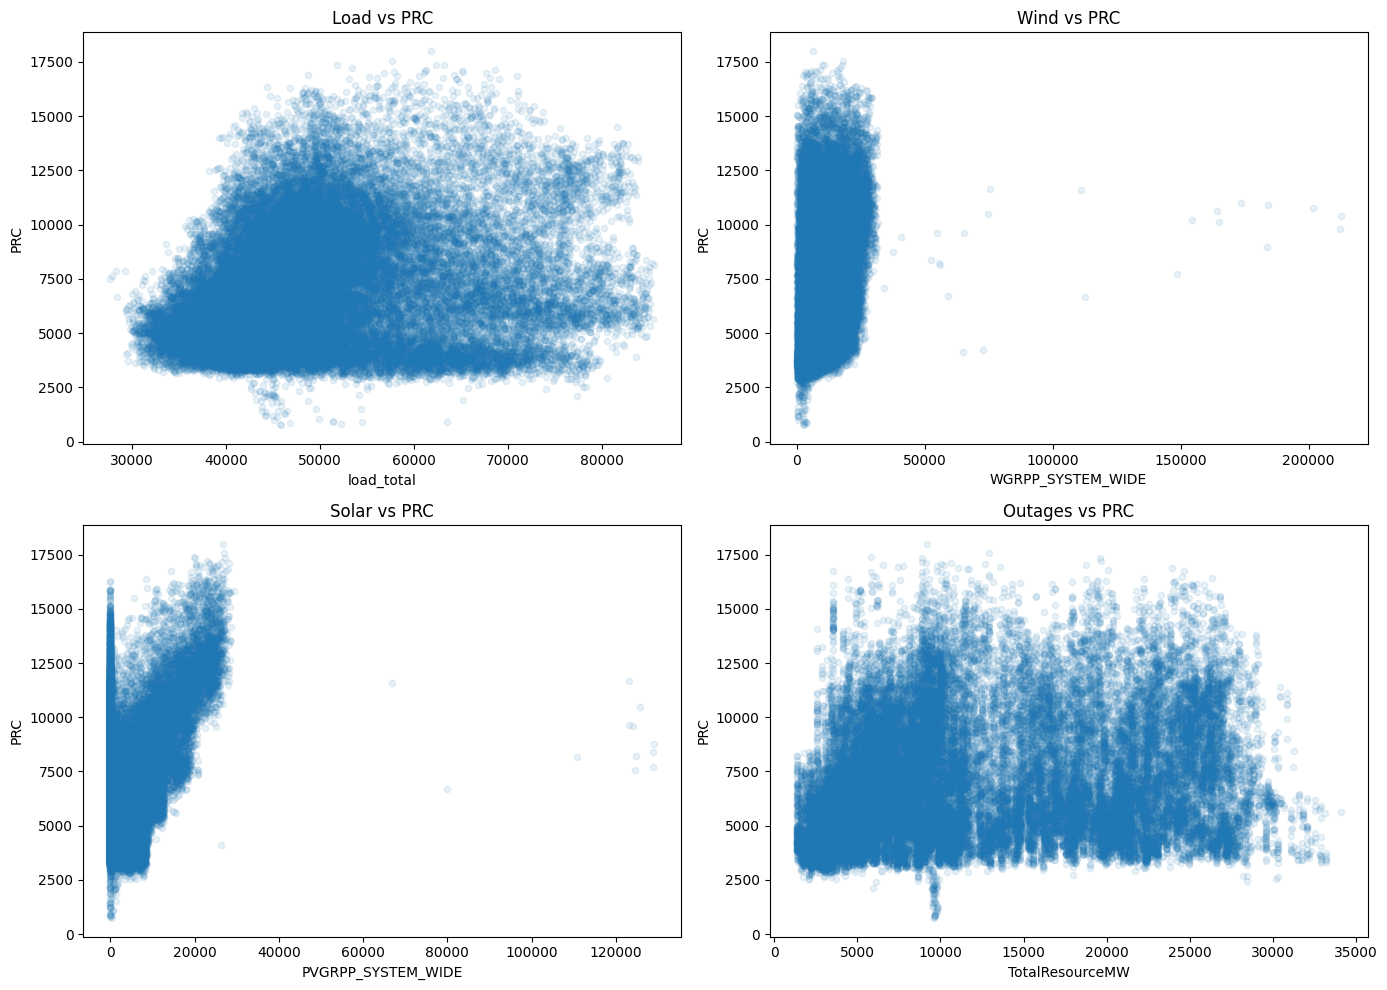

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df.plot.scatter(x='load_total', y='PRC', alpha=0.1, ax=axes[0,0], title='Load vs PRC')
df.plot.scatter(x='WGRPP_SYSTEM_WIDE', y='PRC', alpha=0.1, ax=axes[0,1], title='Wind vs PRC')
df.plot.scatter(x='PVGRPP_SYSTEM_WIDE', y='PRC', alpha=0.1, ax=axes[1,0], title='Solar vs PRC')
df.plot.scatter(x='TotalResourceMW', y='PRC', alpha=0.1, ax=axes[1,1], title='Outages vs PRC')

plt.tight_layout()

In [14]:
print(df[df['net_load'] < -20000][['timestamp', 'load_total', 'WGRPP_SYSTEM_WIDE', 'PVGRPP_SYSTEM_WIDE', 'net_load']].sort_values('net_load'))

                timestamp  load_total  WGRPP_SYSTEM_WIDE  PVGRPP_SYSTEM_WIDE  \
31873 2024-08-21 01:00:00    61546.35           212439.7                 0.0   
31872 2024-08-21 00:00:00    64694.77           212401.4                 0.0   
31874 2024-08-21 02:00:00    59199.07           201769.3                 0.0   
31881 2024-08-21 09:00:00    63409.03            75483.7            123219.8   
31882 2024-08-21 10:00:00    67527.93            74825.7            125734.4   
31875 2024-08-21 03:00:00    57222.83           184132.9                 0.0   
31880 2024-08-21 08:00:00    60233.16           111059.7             66914.0   
31876 2024-08-21 04:00:00    56479.71           173455.2                 0.0   
31883 2024-08-21 11:00:00    71824.79            65222.2            123167.3   
31871 2024-08-20 23:00:00    68802.38           183756.2                 0.0   
31877 2024-08-21 05:00:00    56505.50           164303.8                 0.0   
31878 2024-08-21 06:00:00    57349.40   

<Axes: title={'center': 'Net Load vs PRC (cleaned)'}, xlabel='net_load', ylabel='PRC'>

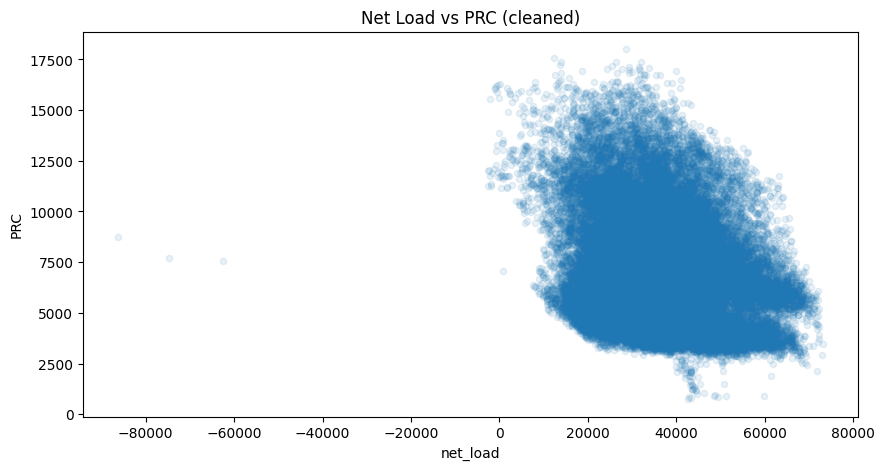

In [15]:
clean = df[df['WGRPP_SYSTEM_WIDE'] < 45000]
clean.plot.scatter(x='net_load', y='PRC', alpha=0.1, figsize=(10, 5), title='Net Load vs PRC (cleaned)')

In [16]:
print(df[(df['net_load'] < -20000) & (df['WGRPP_SYSTEM_WIDE'] < 45000)][['timestamp', 'load_total', 'WGRPP_SYSTEM_WIDE', 'PVGRPP_SYSTEM_WIDE']].head(10))

                timestamp  load_total  WGRPP_SYSTEM_WIDE  PVGRPP_SYSTEM_WIDE
31885 2024-08-21 13:00:00    80507.16            37592.1            129099.3
31886 2024-08-21 14:00:00    82873.13            28814.6            128865.2
31887 2024-08-21 15:00:00    84375.61            22316.4            124468.7


<Axes: title={'center': 'Correlations with PRC'}>

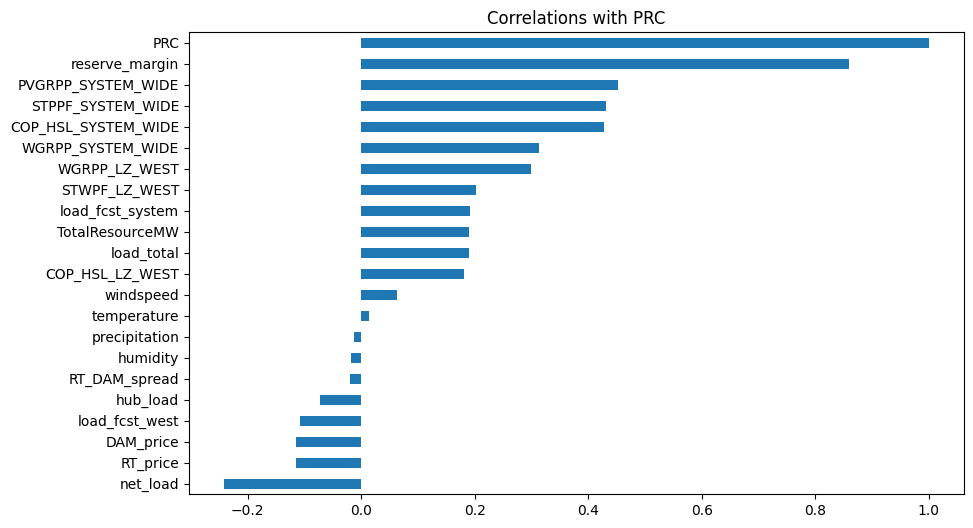

In [17]:
df.corr(numeric_only=True)['PRC'].sort_values().plot(kind='barh', figsize=(10, 6), title='Correlations with PRC')

count    43819.000000
mean      7162.755547
std       2800.554040
min        747.100000
25%       4913.180000
50%       6538.200000
75%       9063.205000
max      18003.160000
Name: PRC, dtype: float64
0.01     3211.003800
0.05     3630.242000
0.10     3967.622000
0.25     4913.180000
0.50     6538.200000
0.75     9063.205000
0.90    11238.836000
0.95    12492.004000
0.99    14630.004233
Name: PRC, dtype: float64


<Axes: >

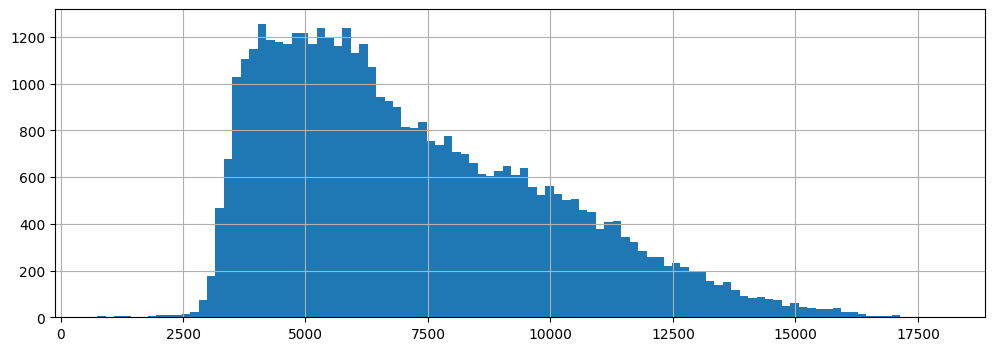

In [8]:
print(df['PRC'].describe())
print(df['PRC'].quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))
df['PRC'].hist(bins=100, figsize=(12, 4))

In [9]:
bins = [0, 3000, 5000, 10000, float('inf')]
labels = ['Scarcity', 'Tight', 'Normal', 'Surplus']
df['regime'] = pd.cut(df['PRC'], bins=bins, labels=labels)
print(df['regime'].value_counts())

regime
Normal      24531
Tight       11383
Surplus      7736
Scarcity      169
Name: count, dtype: int64


In [10]:
print(df[df['regime'] == 'Scarcity'].groupby(df['timestamp'].dt.date).size().sort_index())

timestamp
2021-02-13     1
2021-02-14     1
2021-02-15    24
2021-02-16    24
2021-02-17    16
2021-02-18     4
2021-02-19     2
2021-04-11     2
2021-04-13     3
2021-05-04     1
2021-05-12     1
2021-05-18     1
2021-05-24     3
2021-06-01     2
2021-06-02     5
2021-06-04     2
2021-06-07     1
2021-06-13     4
2021-06-14     3
2021-06-15     2
2021-06-23     1
2021-06-27     1
2021-07-06     5
2021-07-08     2
2021-07-10     3
2021-09-13     2
2021-09-24     1
2021-09-25     1
2021-09-26     1
2021-12-22     1
2021-12-25     1
2021-12-29     1
2022-04-02     1
2022-05-13     1
2022-05-25     1
2022-07-08     1
2022-07-09     2
2022-07-10     3
2022-07-11     1
2022-07-13     7
2022-08-12     3
2022-08-13     1
2022-08-20     1
2022-08-21     1
2022-08-23     1
2022-08-24     2
2022-08-27     1
2022-08-28     2
2022-08-29     1
2022-08-31     4
2022-09-03     2
2022-09-04     1
2022-09-05     2
2022-09-09     1
2022-09-13     1
2022-09-28     1
2022-10-01     1
2022-10-05     1
2023

## Reserve Margin


0.01    0.050872
0.05    0.064709
0.10    0.076478
0.25    0.101789
0.50    0.138169
0.75    0.179703
0.90    0.222546
0.95    0.247192
0.99    0.290980
Name: reserve_margin, dtype: float64


<Axes: >

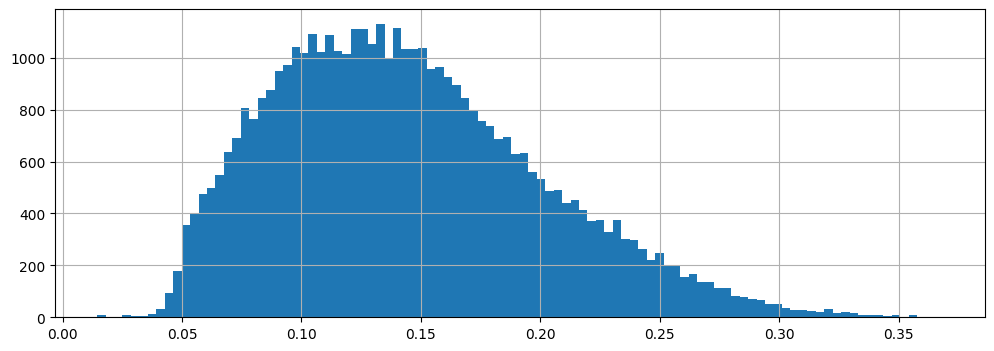

In [11]:
df['reserve_margin'] = df['PRC'] / df['load_total']
print(df['reserve_margin'].quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))
df['reserve_margin'].hist(bins=100, figsize=(12, 4))

## Regime Labels (PRC-based)

| Regime   | PRC Range      | Count  | % of Data | Rationale |
|----------|---------------|--------|-----------|-----------|
| Scarcity | < 3,000 MW    | 169    | 0.4%      | ERCOT emergency alert territory |
| Tight    | 3,000-5,000   | 11,383 | 26.0%     | Price adders begin firing |
| Normal   | 5,000-10,000  | 24,531 | 56.0%     | System operating comfortably |
| Surplus  | > 10,000      | 7,736  | 17.6%     | Excess reserves, high renewables |

Chose absolute PRC over reserve margin % because ERCOT uses absolute MW 
for emergency alerts. 169 scarcity samples spread across 59 distinct days 
and multiple event types (winter storms, summer heat, shoulder season).
3x more scarcity samples than previous price-based labels (50 events).

Text(0.5, 1.0, '2025: RT Price vs PRC')

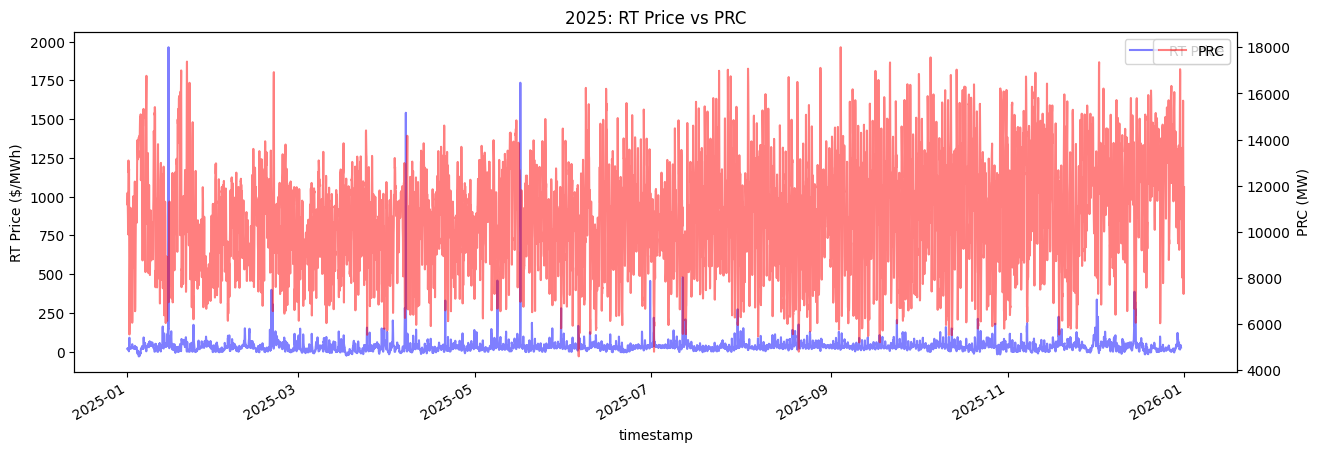

In [18]:
fig, ax1 = plt.subplots(figsize=(15, 5))
ax2 = ax1.twinx()

df[df['timestamp'] >= '2025-01-01'].plot(x='timestamp', y='RT_price', ax=ax1, color='blue', alpha=0.5, label='RT Price')
df[df['timestamp'] >= '2025-01-01'].plot(x='timestamp', y='PRC', ax=ax2, color='red', alpha=0.5, label='PRC')

ax1.set_ylabel('RT Price ($/MWh)')
ax2.set_ylabel('PRC (MW)')
plt.title('2025: RT Price vs PRC')